In [15]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Embedding, concatenate
from tensorflow.keras.models import Model

from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [16]:
# Membaca dataset
df = pd.read_csv('all_agree.csv')

# Lihat 5 baris pertama
print(df.head())
print("\nShape:", df.shape)
print("\nKolom:", df.columns.tolist())

                                               title          label  \
0  Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...  non-clickbait   
1  Malaysia Sudutkan RI: Isu Kabut Asap hingga In...  non-clickbait   
2  Viral! Driver Ojol di Bekasi Antar Pesanan Mak...      clickbait   
3  Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...  non-clickbait   
4  MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...  non-clickbait   

   label_score  
0            0  
1            0  
2            1  
3            0  
4            0  

Shape: (8613, 3)

Kolom: ['title', 'label', 'label_score']


label_score
0    5297
1    3316
Name: count, dtype: int64


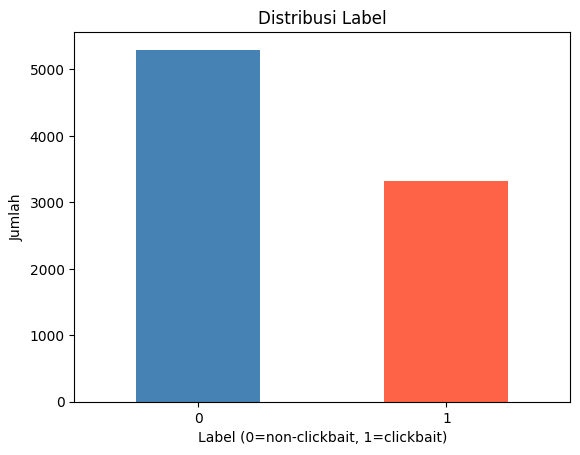

In [17]:
# Cek jumlah data per class
print(df['label_score'].value_counts())

# Visualisasi distribusi
df['label_score'].value_counts().plot(kind='bar',
                                       color=['steelblue','tomato'])
plt.title('Distribusi Label')
plt.xlabel('Label (0=non-clickbait, 1=clickbait)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

In [18]:
# Fungsi menghitung tanda baca
def find_punc(x, punc):
    count = 0
    for char in x:
        if char == punc:
            count += 1
    return count

# Fungsi menghitung huruf kapital
def find_uppercase(x):
    count = 0
    for char in x:
        if char.isupper():
            count += 1
    return count

# Fungsi menghitung huruf kecil
def find_lowercase(x):
    count = 0
    for char in x:
        if char.islower():
            count += 1
    return count

# Fungsi menghitung angka
def find_number(x):
    count = 0
    for char in x:
        if char >= '0' and char <= '9':
            count += 1
    return count

# Terapkan semua fungsi ke kolom title
df['uppercase_count'] = df['title'].apply(find_uppercase)
df['lowercase_count'] = df['title'].apply(find_lowercase)
df['punc'] = df['title'].apply(lambda x: find_punc(x, ',') +
                                          find_punc(x, '.') +
                                          find_punc(x, '!') +
                                          find_punc(x, '?'))
df['number_count'] = df['title'].apply(find_number)

print(df.shape)
print(df.head())

(8613, 7)
                                               title          label  \
0  Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...  non-clickbait   
1  Malaysia Sudutkan RI: Isu Kabut Asap hingga In...  non-clickbait   
2  Viral! Driver Ojol di Bekasi Antar Pesanan Mak...      clickbait   
3  Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...  non-clickbait   
4  MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...  non-clickbait   

   label_score  uppercase_count  lowercase_count  punc  number_count  
0            0               13               45     1             0  
1            0                9               37     0             0  
2            1                9               44     1             0  
3            0                8               43     1             2  
4            0               11               28     0             4  


In [19]:
def clean(text):
    # Lowercase semua huruf
    text = text.lower()
    # Hapus tanda baca
    text = re.sub('[!?:;,.\'\"]', ' ', text)
    # Tokenisasi
    word_tokens = word_tokenize(text)
    # Gabung kembali jadi string
    text = (' ').join(word_tokens)
    return text

# Terapkan fungsi clean ke kolom title
df['cleaned_title'] = df['title'].apply(clean)

# Cek hasilnya
print(df[['title', 'cleaned_title']].head())
print("\nShape:", df.shape)

                                               title  \
0  Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...   
1  Malaysia Sudutkan RI: Isu Kabut Asap hingga In...   
2  Viral! Driver Ojol di Bekasi Antar Pesanan Mak...   
3  Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...   
4  MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...   

                                       cleaned_title  
0  masuk radar pilwalkot medan menantu jokowi ber...  
1  malaysia sudutkan ri isu kabut asap hingga inv...  
2  viral driver ojol di bekasi antar pesanan maka...  
3  kemensos salurkan rp 7 3 m bagi korban kerusuh...  
4  mpr amandemen uud 1945 tak akan melebar ke man...  

Shape: (8613, 8)


In [20]:
# Definisikan X dan y
X = df.iloc[:, 3:]
y = df.iloc[:, 2]

# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=77)

# Cek ukurannya
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6890, 5)
X_test shape: (1723, 5)
y_train shape: (6890,)
y_test shape: (1723,)


In [21]:
# Pisahkan fitur teks dan fitur angka
X_train_title = X_train['cleaned_title']
X_test_title = X_test['cleaned_title']

X_train_punc = X_train.drop('cleaned_title', axis=1)
X_test_punc = X_test.drop('cleaned_title', axis=1)

# Tokenisasi
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_title)

X_train_title = tokenizer.texts_to_sequences(X_train_title)
X_test_title = tokenizer.texts_to_sequences(X_test_title)

# Cek vocab size
vocab_size = len(tokenizer.word_index)
print("Vocab size:", vocab_size)

# Cari panjang kalimat terpanjang
lengths = []
for sentence in X_train_title:
    lengths.append(len(sentence))

print("Longest sentence:", max(lengths))
print("Shortest sentence:", min(lengths))
print("Average length:", np.mean(lengths))

Vocab size: 12290
Longest sentence: 20
Shortest sentence: 2
Average length: 9.771698113207547


In [22]:
# Padding semua sequence ke panjang 19
X_train_title = pad_sequences(X_train_title, maxlen=19)
X_test_title = pad_sequences(X_test_title, maxlen=19)

# Cek shape setelah padding
print("X_train_title shape:", X_train_title.shape)
print("X_test_title shape:", X_test_title.shape)

# Cek shape fitur angka
print("X_train_punc shape:", X_train_punc.shape)
print("X_test_punc shape:", X_test_punc.shape)

X_train_title shape: (6890, 19)
X_test_title shape: (1723, 19)
X_train_punc shape: (6890, 4)
X_test_punc shape: (1723, 4)


In [23]:
# Hitung class weight
class_weights = compute_class_weight('balanced',
                                      classes=np.unique(y_train),
                                      y=y_train)

# Konversi ke dictionary
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.8086854460093896), 1: np.float64(1.3098859315589353)}


In [24]:
# Set random seed supaya hasil konsisten
np.random.seed(99)
tf = __import__('tensorflow')
tf.random.set_seed(99)

# Tentukan ukuran input
lstm_input = 19   # panjang sequence
mlp_input  = 4    # jumlah fitur angka
vocab_size_model = vocab_size + 1  # tambah 1 untuk padding
output_dim = 32   # dimensi embedding

# ============ CABANG 1: LSTM ============
input_1 = Input(shape=(lstm_input,))
stm = Embedding(vocab_size_model, output_dim, input_length=lstm_input)(input_1)
stm = LSTM(3)(stm)
stm = Dropout(rate=0.5)(stm)
lstm_model = stm

# ============ CABANG 2: MLP ============
input_2 = Input(shape=(mlp_input,))
dense = Dense(3, activation='sigmoid')(input_2)
dense = Dense(6, activation='sigmoid')(dense)
dense = Dropout(rate=0.5)(dense)
dense_model = dense

# ============ GABUNGKAN KEDUANYA ============
concat = concatenate([lstm_model, dense_model])
dense = Dense(1, activation='sigmoid')(concat)
dense = Dense(3, activation='sigmoid')(concat)
dense = Dense(2, activation='sigmoid')(dense)
dense = Dense(1, activation='sigmoid')(dense)

# Buat model final
model = Model(inputs=[input_1, input_2], outputs=dense)

# Lihat struktur model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 19, 32)    │    393,312 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 3)         │         15 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 3)         │        432 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 6)         │         24 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 3)         │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 6)         │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 9)         │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 3)         │         30 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 2)         │          8 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │          3 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 393,824 (1.50 MB)

 Trainable params: 393,824 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Compile model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['acc'])

# Training model
history = model.fit(
    [X_train_title, X_train_punc], y_train,
    batch_size=64,
    epochs=4,
    validation_data=([X_test_title, X_test_punc], y_test),
    class_weight=class_weight_dict
)

Epoch 1/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.6183 - loss: 0.7102 - val_acc: 0.6019 - val_loss: 0.6760
Epoch 2/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - acc: 0.6183 - loss: 0.6936 - val_acc: 0.6019 - val_loss: 0.6779
Epoch 3/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - acc: 0.7134 - loss: 0.6787 - val_acc: 0.8590 - val_loss: 0.6646
Epoch 4/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.8679 - loss: 0.6509 - val_acc: 0.8671 - val_loss: 0.6324


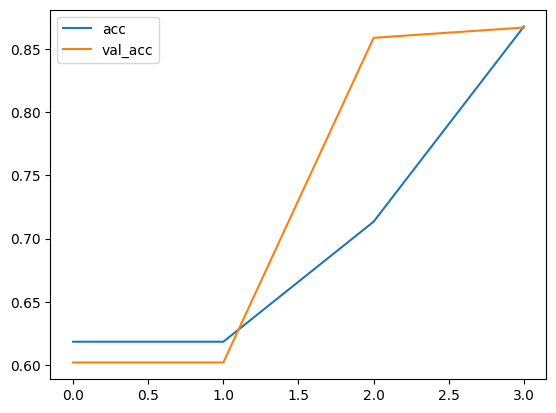

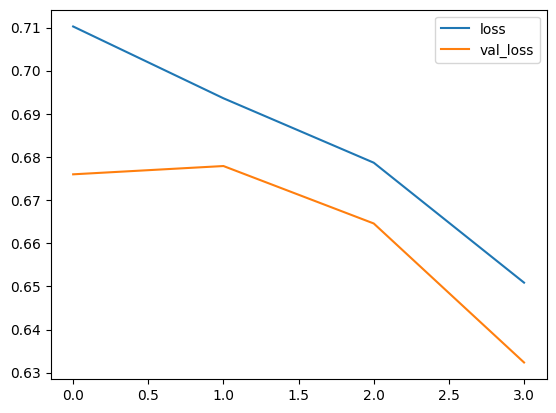

In [26]:
# Grafik Akurasi
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['acc', 'val_acc'])
plt.show()

# Grafik Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Accuracy: 0.8670922809053976

Classification Report:
               precision    recall  f1-score   support

non-clickbait       0.89      0.89      0.89      1037
    clickbait       0.83      0.83      0.83       686

     accuracy                           0.87      1723
    macro avg       0.86      0.86      0.86      1723
 weighted avg       0.87      0.87      0.87      1723



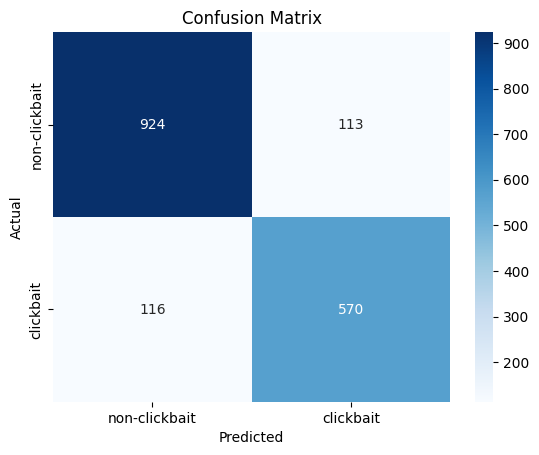

In [27]:
# Prediksi data test
y_pred = model.predict([X_test_title, X_test_punc])

# Konversi ke binary (0 atau 1)
y_pred = (y_pred > 0.5).astype(int)

# Hitung akurasi
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['non-clickbait', 'clickbait']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-clickbait', 'clickbait'],
            yticklabels=['non-clickbait', 'clickbait'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [28]:
# Simpan model
model.save('clickbait_detector.h5')
print("Model berhasil disimpan!")

# Simpan tokenizer
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizer berhasil disimpan!")


Model berhasil disimpan!
Tokenizer berhasil disimpan!
